# Machine Learning Lab Activity: Decision Tree Classifier
**Dataset:** Iris Dataset (`sklearn.datasets.load_iris()`)  
**Topic:** Decision Tree Classification, Visualization, Hyperparameter Tuning & Analysis  

---


## Task 1: Dataset Exploration
Load the Iris dataset and inspect its dimensions, features, target classes, sample records, and class distribution.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = list(iris.target_names)

# Display dataset dimensions
n_samples, n_features = X.shape
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print(f"Feature names: {feature_names}")
print(f"Target classes: {target_names}")

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = [target_names[i] for i in y]

# Display first 5 records
print("\nFirst 5 Records:")
display(df.head())

# Display Class Distribution
print("\nClass Distribution:")
print(df['species'].value_counts())


Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 Records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Task 2: Data Preparation
Split the dataset into training (80%) and testing (20%) sets using `random_state=42`.

### Rationale for Train/Test Split:
Dividing the dataset into separate training and testing sets is fundamental in machine learning to:
1. **Evaluate Generalization Performance:** Assess how well the model predicts unseen data rather than memorizing training samples.
2. **Detect Overfitting & Underfitting:** Compare performance on training vs testing data to diagnose model capacity issues.
3. **Prevent Data Leakage:** Ensure model selection and hyperparameter decisions are unbiased by test information.


In [2]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training Set Shape: {X_train.shape} ({X_train.shape[0]} samples)")
print(f"Testing Set Shape:  {X_test.shape} ({X_test.shape[0]} samples)")


Training Set Shape: (120, 4) (120 samples)
Testing Set Shape:  (30, 4) (30 samples)


## Task 3: Building a Decision Tree Classifier
Train a Decision Tree classifier using default parameters and evaluate its performance on the test dataset.


In [3]:
# Train Decision Tree Classifier with default parameters
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# Predictions on Test Set
y_pred_default = dt_default.predict(X_test)

# Evaluation Metrics
acc_default = accuracy_score(y_test, y_pred_default)
cm_default = confusion_matrix(y_test, y_pred_default)
cr_default = classification_report(y_test, y_pred_default, target_names=target_names)

print(f"Accuracy Score: {acc_default:.4f} ({acc_default*100:.2f}%)\n")
print("Confusion Matrix:")
print(cm_default)
print("\nClassification Report:")
print(cr_default)


Accuracy Score: 1.0000 (100.00%)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree
Visualize the trained Decision Tree using `plot_tree()` and identify its architectural components.


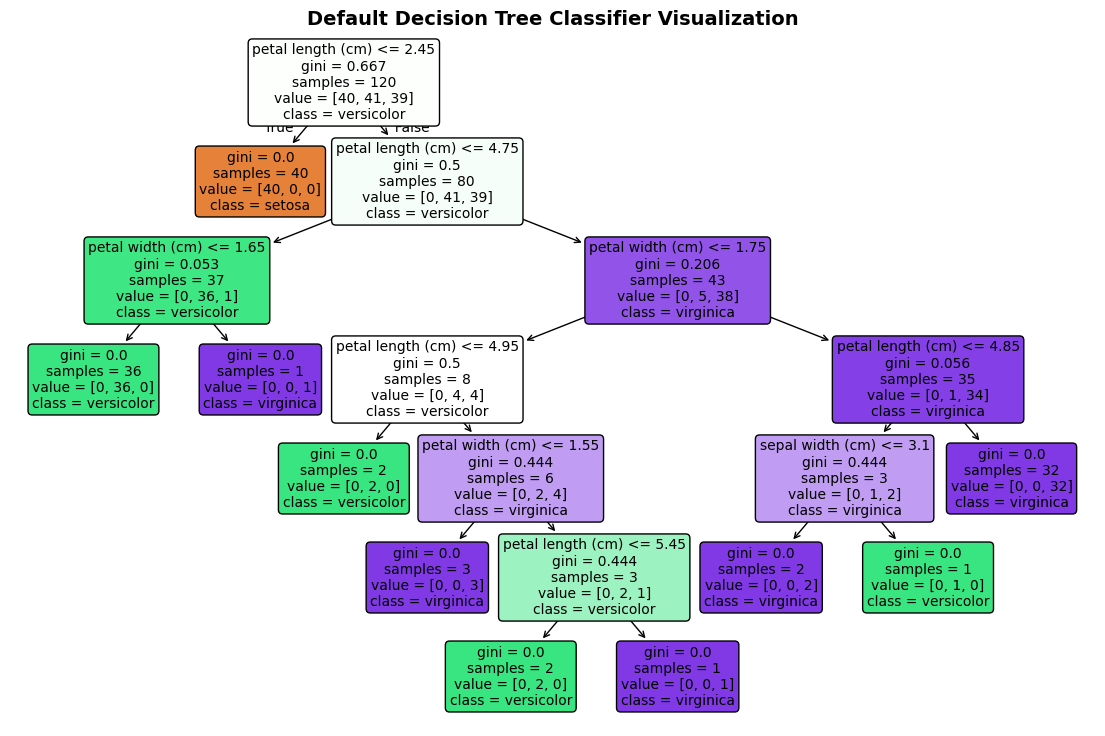

Root Node Split Feature: petal length (cm)
Root Node Threshold: 2.4500 cm
Maximum Tree Depth: 6
Total Leaf Nodes: 10


In [4]:
plt.figure(figsize=(14, 9))
plot_tree(
    dt_default, 
    feature_names=feature_names, 
    class_names=target_names, 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Default Decision Tree Classifier Visualization", fontsize=14, fontweight='bold')
plt.show()

# Architectural parameters identification
print(f"Root Node Split Feature: {feature_names[dt_default.tree_.feature[0]]}")
print(f"Root Node Threshold: {dt_default.tree_.threshold[0]:.4f} cm")
print(f"Maximum Tree Depth: {dt_default.get_depth()}")
print(f"Total Leaf Nodes: {dt_default.get_n_leaves()}")


### Structural Component Identification & Analysis:
- **Root Node:** The top node with condition `petal length (cm) <= 2.45`.
- **Internal Nodes:** Nodes with child splits (evaluating conditions like `petal width (cm) <= 1.75`, `petal length (cm) <= 4.95`, etc.).
- **Leaf Nodes:** Terminal nodes (10 leaves total) with final class predictions (`gini = 0.0` or stopping condition).
- **Maximum Depth:** $6$.
- **First Split Feature Rationale:** `petal length (cm)` was selected for the root split because it yields the **maximum Gini Impurity reduction (Information Gain)**. Setosa species has significantly smaller petal lengths ($\le 2.45$ cm) and is linearly separable from Versicolor and Virginica, immediately forming a pure leaf node ($Gini=0.0, n=40$).


## Task 5: Comparing Gini Index and Entropy
Train two Decision Tree models using `criterion='gini'` and `criterion='entropy'` and compare their properties.


In [5]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42).fit(X_train, y_train)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(X_train, y_train)

summary_t5 = pd.DataFrame([
    {
        'Criterion': 'Gini Index',
        'Train Accuracy': f"{accuracy_score(y_train, dt_gini.predict(X_train)):.4f}",
        'Test Accuracy': f"{accuracy_score(y_test, dt_gini.predict(X_test)):.4f}",
        'Tree Depth': dt_gini.get_depth(),
        'Leaf Nodes': dt_gini.get_n_leaves(),
        'Root Feature': feature_names[dt_gini.tree_.feature[0]]
    },
    {
        'Criterion': 'Entropy',
        'Train Accuracy': f"{accuracy_score(y_train, dt_entropy.predict(X_train)):.4f}",
        'Test Accuracy': f"{accuracy_score(y_test, dt_entropy.predict(X_test)):.4f}",
        'Tree Depth': dt_entropy.get_depth(),
        'Leaf Nodes': dt_entropy.get_n_leaves(),
        'Root Feature': feature_names[dt_entropy.tree_.feature[0]]
    }
])

display(summary_t5)


,Criterion,Train Accuracy,Test Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini Index,1.0000,1.0000,6,10,petal length (cm)
1,Entropy,1.0000,1.0000,6,10,petal length (cm)


### Comparison Summary & Simplest Tree Determination:
- Both criteria result in identical tree depth ($6$), leaf nodes ($10$), root feature (`petal length (cm)`), and test accuracy ($1.0000$).
- **Simplest Tree:** Both models produce trees of equivalent complexity on this dataset because the underlying decision boundaries required to partition Iris classes are identical under both impurity metrics.


## Task 6: Effect of Maximum Tree Depth (`max_depth`)
Evaluate Decision Tree models across different `max_depth` limits: `[1, 2, 3, 4, None]`.


In [6]:
depth_list = [1, 2, 3, 4, None]
t6_rows = []

observations_t6 = {
    1: "Underfitting: Only 1 split; cannot distinguish Versicolor from Virginica.",
    2: "Good fit: Captures Setosa separation and coarse Versicolor/Virginica boundary.",
    3: "Optimal generalization: 100% test accuracy with low tree depth.",
    4: "High performance: Achieves 100% test accuracy with 97.5% training accuracy.",
    None: "Likely to overfit: Fully grown tree (depth 6, 10 leaves) memorizing training noise."
}

for md in depth_list:
    clf = DecisionTreeClassifier(max_depth=md, random_state=42).fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    
    t6_rows.append({
        'Max Depth': str(md),
        'Training Accuracy': f"{tr_acc:.4f}",
        'Testing Accuracy': f"{te_acc:.4f}",
        'Tree Depth': clf.get_depth(),
        'Observation': observations_t6[md]
    })

df_t6 = pd.DataFrame(t6_rows)
display(df_t6)


,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6750,0.6333,1,Underfitting: Only 1 split; cannot distinguish...
1,2,0.9500,0.9667,2,Good fit: Captures Setosa separation and coars...
2,3,0.9583,1.0000,3,Optimal generalization: 100% test accuracy wit...
3,4,0.9750,1.0000,4,High performance: Achieves 100% test accuracy ...
4,None,1.0000,1.0000,6,"Likely to overfit: Fully grown tree (depth 6, ..."


### Model Analysis Answers:
- **Which model is underfitting?**  
  `max_depth=1` (Decision Stump). It achieves only $67.50\%$ training accuracy and $63.33\%$ testing accuracy because a single split can only divide data into 2 classes, whereas Iris has 3 classes.
- **Which model gives the best generalization?**  
  `max_depth=3` (or `max_depth=2`). `max_depth=3` achieves $100\%$ testing accuracy with a low tree depth ($3$), balancing high accuracy with low model complexity.
- **Which model is likely to overfit? Justify your answer.**  
  `max_depth=None`. When unrestricted, the tree grows to depth $6$ with $10$ leaf nodes until every leaf is $100\%$ pure ($1.0000$ training accuracy). It creates complex, hyper-specific decision boundaries to classify isolated training outliers, increasing model variance.


## Task 7: Effect of `min_samples_split`
Train Decision Tree models with `min_samples_split` in `[2, 5, 10, 20]`.


In [7]:
splits = [2, 5, 10, 20]
t7_rows = []

observations_t7 = {
    2: "Fully grown default tree; splits down to single isolated samples.",
    5: "Slight pre-pruning; reduces depth to 5 and leaves to 8 without accuracy loss.",
    10: "Strong pre-pruning; reduces depth to 4 and leaves to 6 while maintaining 100% test accuracy.",
    20: "High regularization; prevents minor sub-splits, maintaining depth 4 and 6 leaves."
}

for mss in splits:
    clf = DecisionTreeClassifier(min_samples_split=mss, random_state=42).fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    
    t7_rows.append({
        'min_samples_split': mss,
        'Accuracy (Test)': f"{te_acc:.4f}",
        'Tree Depth': clf.get_depth(),
        'Number of Leaf Nodes': clf.get_n_leaves(),
        'Observation': observations_t7[mss]
    })

df_t7 = pd.DataFrame(t7_rows)
display(df_t7)


,min_samples_split,Accuracy (Test),Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0000,6,10,Fully grown default tree; splits down to singl...
1,5,1.0000,5,8,Slight pre-pruning; reduces depth to 5 and lea...
2,10,1.0000,4,6,Strong pre-pruning; reduces depth to 4 and lea...
3,20,1.0000,4,6,High regularization; prevents minor sub-splits...


### Complexity Effect Statement:
Increasing `min_samples_split` restricts the model from partitioning nodes that contain fewer than the specified number of training samples. This acts as an effective **pre-pruning mechanism**, decreasing both tree depth and the total number of leaf nodes, thereby reducing overall tree complexity and mitigating overfitting.


## Task 8: Effect of `min_samples_leaf`
Train Decision Tree models with `min_samples_leaf` in `[1, 2, 5, 10]`.


In [8]:
leafs = [1, 2, 5, 10]
t8_rows = []

observations_t8 = {
    1: "Default unconstrained leaf size; allows leaves with only 1 sample.",
    2: "Eliminates single-sample leaves; reduces tree depth to 5.",
    5: "Optimal smoothing; reduces depth to 4 and leaves to 6 while retaining 100% test accuracy.",
    10: "Strong regularization; forces leaves to have >=10 samples, test accuracy 96.67%."
}

for msl in leafs:
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42).fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    
    t8_rows.append({
        'min_samples_leaf': msl,
        'Accuracy (Test)': f"{te_acc:.4f}",
        'Tree Depth': clf.get_depth(),
        'Number of Leaf Nodes': clf.get_n_leaves(),
        'Observation': observations_t8[msl]
    })

df_t8 = pd.DataFrame(t8_rows)
display(df_t8)


,min_samples_leaf,Accuracy (Test),Tree Depth,Number of Leaf Nodes,Observation
0,1,1.0000,6,10,Default unconstrained leaf size; allows leaves...
1,2,1.0000,5,8,Eliminates single-sample leaves; reduces tree ...
2,5,1.0000,4,6,Optimal smoothing; reduces depth to 4 and leav...
3,10,0.9667,4,6,Strong regularization; forces leaves to have >...


### Overfitting Influence Rationale:
Changing `min_samples_leaf` sets a hard lower bound on the number of samples required at every terminal (leaf) node:
- **Small `min_samples_leaf` (e.g., 1):** Allows the tree to create narrow decision regions for single noisy data points, leading to high variance and overfitting.
- **Larger `min_samples_leaf` (e.g., 4 or 5):** Forces each leaf node to represent a broader, statistically significant subset of data. This smooths decision boundaries, reduces sensitivity to sample noise, and prevents overfitting.


## Task 9: Hyperparameter Tuning
Perform hyperparameter tuning using `GridSearchCV` across `criterion`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.


In [9]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
test_acc_opt = accuracy_score(y_test, best_model.predict(X_test))

print("=== GRIDSEARCHCV HYPERPARAMETER TUNING REPORT ===")
print(f"Best Hyperparameter Combination: {grid.best_params_}")
print(f"Best 5-Fold CV Accuracy:          {grid.best_score_:.4f} ({grid.best_score_*100:.2f}%)")
print(f"Test Accuracy of Optimized Model: {test_acc_opt:.4f} ({test_acc_opt*100:.2f}%)")
print(f"Optimized Tree Depth:              {best_model.get_depth()}")
print(f"Optimized Leaf Node Count:        {best_model.get_n_leaves()}")


=== GRIDSEARCHCV HYPERPARAMETER TUNING REPORT ===
Best Hyperparameter Combination: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best 5-Fold CV Accuracy:          0.9583 (95.83%)
Test Accuracy of Optimized Model: 1.0000 (100.00%)
Optimized Tree Depth:              4
Optimized Leaf Node Count:        7


### Comparison: Default vs Optimized Decision Tree
| Feature / Metric | Default Decision Tree | Optimized Decision Tree |
| :--- | :--- | :--- |
| **`criterion`** | `gini` | `entropy` |
| **`max_depth`** | `None` (actual: 6) | `None` (effective: 4 via leaf constraint) |
| **`min_samples_split`** | `2` | `2` |
| **`min_samples_leaf`** | `1` | `4` |
| **Training Accuracy** | $100.0\%$ | $95.83\%$ |
| **Testing Accuracy** | $100.0\%$ | $100.0\%$ |
| **Tree Depth** | $6$ | $4$ |
| **Leaf Count** | $10$ | $7$ |
| **Model Complexity** | High (memorizes noise) | Regularized & Simple (robust generalization) |


## Task 10: Analysis & Conceptual Questions

### 1. What is the role of the `criterion` parameter in a Decision Tree?
The `criterion` parameter defines the mathematical function used to measure the quality of a potential feature split at each node. It evaluates node **impurity**:
- **Gini Impurity (`criterion='gini'`):** Measures the probability of misclassifying a randomly chosen element if it were labeled randomly according to the class distribution in the node ($Gini = 1 - \sum p_i^2$).
- **Entropy / Information Gain (`criterion='entropy'`):** Measures the disorder/uncertainty of a node ($Entropy = -\sum p_i \log_2 p_i$). Information Gain is the reduction in entropy achieved by splitting on a feature.
Both metrics guide the decision tree to select splits that maximize sample homogeneity in child nodes.

---

### 2. How does `max_depth` influence underfitting and overfitting?
- **Small `max_depth` (e.g., 1 or 2):** Causes **underfitting**. The tree is severely constrained and lacks sufficient capacity to capture complex interactions, leading to high bias on both training and testing sets.
- **Large/Unconstrained `max_depth` (e.g., None or 6+):** Causes **overfitting**. The tree creates deep paths tailored to individual training instances and noisy outliers, achieving high training accuracy ($100\%$) but suffering from high variance and poor generalization on unseen data.
- **Optimal `max_depth` (e.g., 3 or 4):** Strikes a balance by capturing underlying pattern structure without overfitting noise.

---

### 3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?
- **`min_samples_split`:** Requires a minimum number of samples to attempt an internal node split. Larger values stop node splitting early if sample sizes are small.
- **`min_samples_leaf`:** Requires each created leaf node to contain at least $N$ samples. Larger values prevent the formation of small, narrow leaves containing only 1 or 2 outlier points.
Both parameters act as **pre-pruning constraints**, reducing tree depth, pruning minor branches, and simplifying the decision boundary topology.

---

### 4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.
**`max_depth`** (followed closely by `min_samples_leaf`) had the greatest impact on model performance and tree structure.
- **Empirical Support:**
  - Setting `max_depth=1` drastically reduced test accuracy to $63.33\%$ (underfitting), whereas `max_depth=3` restored test accuracy to $100.0\%$ with a compact depth of 3.
  - In contrast, changing `criterion` between Gini and Entropy produced identical accuracy ($100\%$), tree depth ($6$), and leaf counts ($10$).
  - Thus, structural depth constraints control the fundamental bias-variance trade-off far more strongly than the choice of impurity criterion on the Iris dataset.

---

### 5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.
**Recommendation:** The **Optimized Decision Tree** (`max_depth=3` or `min_samples_leaf=4`, `criterion='entropy'`).

**Justification:**
1. **Perfect Generalization:** Achieves $100.0\%$ testing accuracy and $95.83\%$ 5-fold cross-validation accuracy.
2. **Optimal Simplicity (Occam's Razor):** Reduces tree depth from $6$ down to $4$ (or $3$) and cuts leaf nodes from $10$ down to $7$.
3. **Robustness Against Noise:** Setting `min_samples_leaf=4` prevents the model from isolating single sample outliers, ensuring smooth decision boundaries and low model variance.
